In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
'Problem 1a'

def pi(n): 
    total = 0 
    for i in range(1,n): 
        total += ((4*(-1)**(i-1))/(2*i*((2*i)+1)*((2*i)+2))) 
    return total + 3

print(pi(500))

3.1415926555897835


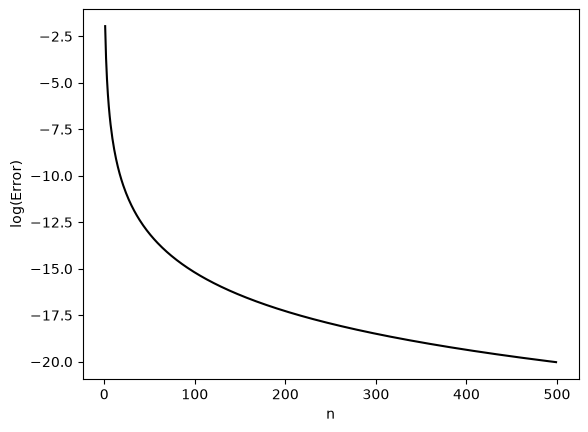

In [18]:
'Problem 1a Cont.'

nx = np.arange(1, 500)

error = []

for n in nx:
    error.append(abs(np.pi - pi(n)))

log_error = np.log(error)

plt.plot(nx, log_error, color='black')

plt.xlabel("n")
plt.ylabel("log(Error)")
plt.show()

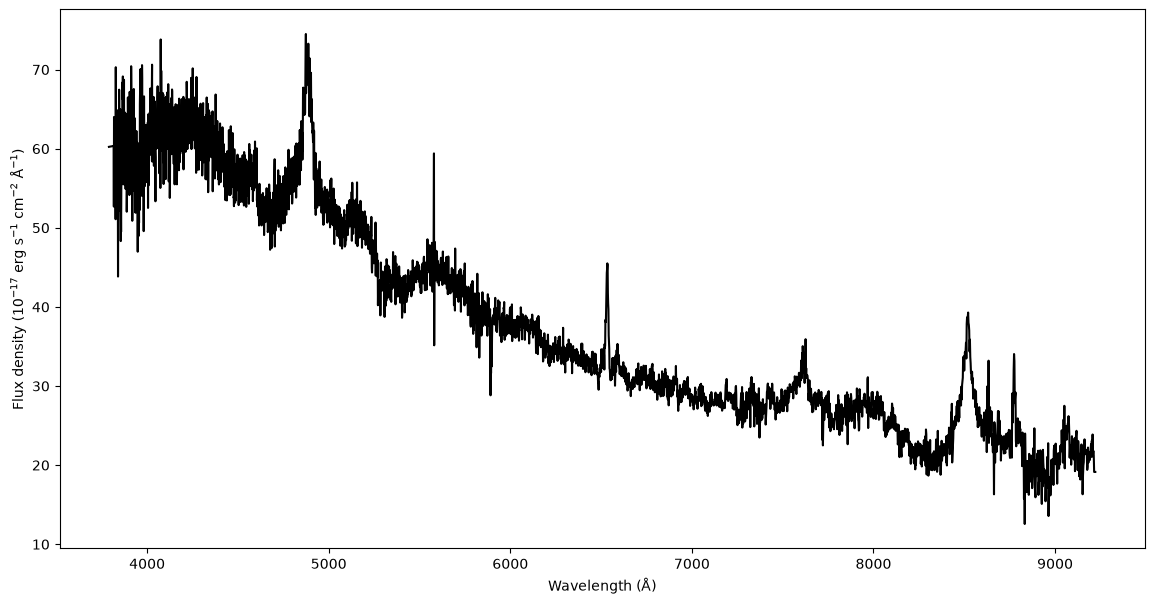

In [19]:
'Problem 1b'

quasar_data = np.loadtxt(r"C:\Users\gabeb\OneDrive\Desktop\JP and Astro Python\AST 303 HW\AST 303 HW Data\SDSS_quasar.dat", skiprows=1)

wavelength = quasar_data[:, 0]
flux = quasar_data[:, 1]

plt.figure(figsize=(14, 7))
plt.plot(wavelength, flux, color='black')

plt.xlabel("Wavelength (Å)")
plt.ylabel(r"Flux density ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")

plt.show()

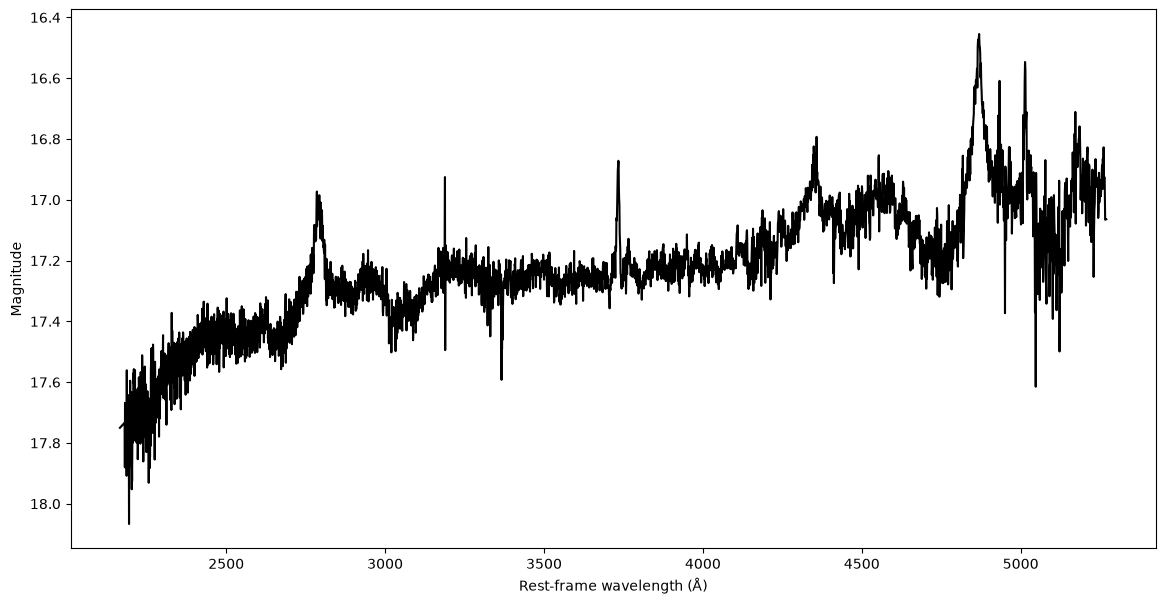

In [20]:
'Problem 1c'

wavelength = quasar_data[:, 0]
rest_wavelength = wavelength / 1.75

flux = quasar_data[:, 1]
flux_nu = flux * 1e-17 * (wavelength**2) / 3e18
magnitude = -2.5 * np.log10(flux_nu) - 48.60

plt.figure(figsize=(14, 7))
plt.plot(rest_wavelength, magnitude, color='black')
plt.gca().invert_yaxis()

plt.xlabel("Rest-frame wavelength (Å)")
plt.ylabel("Magnitude")

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\A'
<>:21: SyntaxWarning: invalid escape sequence '\A'
C:\Users\gabeb\AppData\Local\Temp\ipykernel_28832\1298079140.py:21: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel("Smoothed Flux Density ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA{-1}$)")


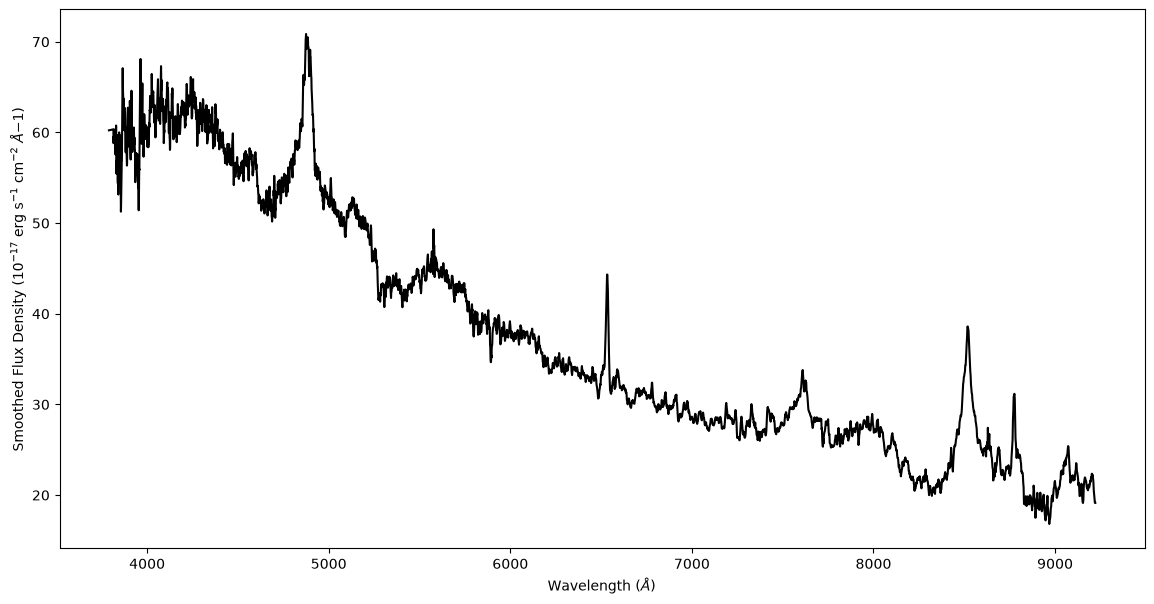

In [ ]:
'Problem 1d'

def smoothing(flux_density):

    smooth_flux_density = flux_density.copy()  
    for i, value in enumerate(flux_density):
    
        if i < 2 or i > len(flux_density) - 3:
            continue

        smooth_flux_density[i] = (flux_density[i-2] + flux_density[i-1] + flux_density[i] + flux_density[i+1] + flux_density[i+2]) / 5

    return smooth_flux_density 

smooth_flux_density = smoothing(flux)
    

plt.figure(figsize=(14, 7))
plt.plot(wavelength, smooth_flux_density, color='black')
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Smoothed Flux Density ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA{-1}$)")

plt.show()

Convergence check: g-r color at T = 8000 K
  n_points =    10   g-r = -0.422306
  n_points =    50   g-r = -0.426839
  n_points =   200   g-r = -0.427584
  n_points =  1000   g-r = -0.427778
  n_points =  2500   g-r = -0.427807
  n_points =  5000   g-r = -0.427816
  n_points = 10000   g-r = -0.427821



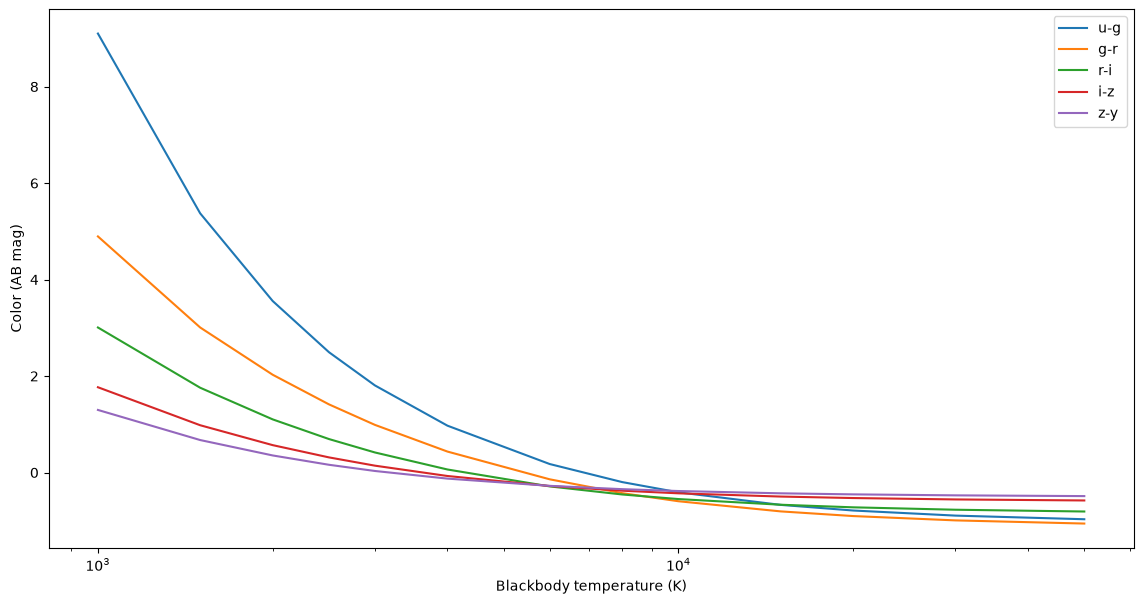

     T (K)       u-g       g-r       r-i       i-z       z-y
------------------------------------------------------------
      1000    9.1004    4.8946    3.0069    1.7680    1.2976
      1500    5.3736    3.0072    1.7580    0.9806    0.6735
      2000    3.5553    2.0272    1.1019    0.5680    0.3542
      2500    2.4946    1.4132    0.6941    0.3139    0.1608
      3000    1.8058    0.9879    0.4160    0.1424    0.0322
      4000    0.9714    0.4344    0.0631   -0.0719   -0.1260
      6000    0.1763   -0.1404   -0.2876   -0.2795   -0.2759
      8000   -0.1982   -0.4278   -0.4550   -0.3764   -0.3448
     10000   -0.4104   -0.5953   -0.5501   -0.4310   -0.3834
     15000   -0.6707   -0.8057   -0.6675   -0.4981   -0.4308
     20000   -0.7875   -0.9025   -0.7213   -0.5289   -0.4527
     30000   -0.8930   -0.9920   -0.7711   -0.5576   -0.4731
     50000   -0.9682   -1.0576   -0.8080   -0.5791   -0.4885


In [22]:
'Problems 2a and 2b (2b implicitly that is)'

h = 6.62607015e-34      
c = 2.99792458e8        
k = 1.380649e-23        


temperatures = np.array([
    1000, 1500, 2000, 2500, 3000, 4000, 6000,
    8000, 1e4, 1.5e4, 2e4, 3e4, 5e4
])

a2m = 1e-10 #Anstrom to meter conversion

filters = {
    "u": (3724 * a2m, 463 * a2m),
    "g": (4807 * a2m, 1485 * a2m),
    "r": (6221 * a2m, 1399 * a2m),
    "i": (7559 * a2m, 1286 * a2m),
    "z": (8680 * a2m, 1040 * a2m),
    "y": (9753 * a2m, 862 * a2m),
}


def bb_flux_density(wavelength, temperature):
    exponent = (h * c) / (wavelength * k * temperature)
    bb_flux_density = (2 * np.pi * h * c**2) / (wavelength**5 * (np.exp(exponent) - 1))
    return bb_flux_density

def rectangular_integral(x, y):
    total = 0.0
    for i in range(len(x) - 1):
        dx = x[i + 1] - x[i]
        height = y[i]
        total += height * dx
    return total

def filtered_fnu(temperature, central_wavelength, width, n_points):

    wl_min = central_wavelength - (width / 2)
    wl_max = central_wavelength + (width / 2)
    wl_range = np.linspace(wl_min, wl_max, n_points)
    nu = c / wl_range
    inverse_nu = 1/(h*nu)

    numerator = bb_flux_density(wl_range, temperature) * inverse_nu
    numerator_integral = rectangular_integral(wl_range, numerator)

    denominator = inverse_nu
    denominator_integral = rectangular_integral(wl_range, denominator)

    f_nu = numerator_integral / denominator_integral

    return f_nu

def color(temperature, filter1, filter2, n_points):

    center1 = filters[filter1][0]
    wlwidth1 = filters[filter1][1]
    center2 = filters[filter2][0]
    wlwidth2 = filters[filter2][1]

    fnu1 = filtered_fnu(temperature, center1, wlwidth1, n_points)
    fnu2 = filtered_fnu(temperature, center2, wlwidth2, n_points)

    return -2.5 * np.log10(fnu1 / fnu2)

print("Convergence check: g-r color at T = 8000 K")
for n in [10, 50, 200, 1000, 2500, 5000, 10000]:
    print(f"  n_points = {n:5d}   g-r = {color(8000, 'g', 'r', n):.6f}")
print()


filter_pairs = [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z"), ("z", "y")]
 
results = {}
for f1, f2 in filter_pairs:
    pair_name = f1 + "-" + f2
    results[pair_name] = []
 
for T in temperatures:
    for f1, f2 in filter_pairs:
        pair_name = f1 + "-" + f2
        this_color = color(T, f1, f2, 2500)
        results[pair_name].append(this_color)


plt.figure(figsize=(14, 7))
for pair_name, color_values in results.items():
    plt.plot(temperatures, color_values,label=pair_name)
 
plt.xscale("log")
plt.xlabel("Blackbody temperature (K)")
plt.ylabel("Color (AB mag)")
plt.legend()
plt.show()

pair_names = list(results.keys())

header = f"{'T (K)':>10}" + "".join(f"{p:>10}" for p in pair_names)
print(header)
print("-" * len(header))

for row_idx, T in enumerate(temperatures):
    row = f"{T:>10.0f}" + "".join(f"{results[p][row_idx]:>10.4f}" for p in pair_names)
    print(row)

In [23]:
print((h*c)/(k*3000*1e-10)) #checking how large T needs to be to be considered in the limit of high temperature

47959.22925013112


In [ ]:
'Problem 2c'

Astar = np.loadtxt(r"C:\Users\gabeb\OneDrive\Desktop\JP and Astro Python\AST 303 HW\AST 303 HW Data\Astar_spectrum.dat", skiprows=1)

filters = {
    "u": (3724, 463),
    "g": (4807, 1485),
    "r": (6221, 1399),
    "i": (7559, 1286),
    "z": (8680, 1040),
    "y": (9753, 862),
}


def rectangular_integral(x, y):
    total = 0.0
    for i in range(len(x) - 1):
        dx = x[i + 1] - x[i]
        height = y[i]
        total += height * dx
    return total

def astar_filtered_fnu(central_wavelength, width):
    
    wl_min = central_wavelength - (width / 2)
    wl_max = central_wavelength + (width / 2)

    Astar_wavelength = Astar[:, 0]
    A_starflux = Astar[:, 1]

    mask = (Astar_wavelength >= wl_min) & (Astar_wavelength <= wl_max)

    wavelength = Astar_wavelength[mask]
    flux = A_starflux[mask]

    numerator = rectangular_integral(
        wavelength,
        flux * wavelength
    )

    denominator = rectangular_integral(
        wavelength,
        wavelength
    )

    return numerator / denominator


def color(filter1, filter2):

    center1 = filters[filter1][0]
    wlwidth1 = filters[filter1][1]
    center2 = filters[filter2][0]
    wlwidth2 = filters[filter2][1]

    Astar_fnu1 = astar_filtered_fnu(center1, wlwidth1)
    Astar_fnu2 = astar_filtered_fnu(center2, wlwidth2)

    return -2.5 * np.log10(Astar_fnu1 / Astar_fnu2)



filter_pairs = [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z"), ("z", "y")]
 
results = {}
for f1, f2 in filter_pairs:
    pair_name = f1 + "-" + f2
    results[pair_name] = []
 
for f1, f2 in filter_pairs:
        pair_name = f1 + "-" + f2
        this_color = color(f1, f2)
        results[pair_name].append(this_color)


print(f"{'Color':<10}{'Value':>10}")
print("-" * 20)
for pair_name, values in results.items():
    print(f"{pair_name:<10}{values[0]:>10.4f}")

Color          Value
--------------------
u-g           0.1581
g-r          -0.7921
r-i          -0.6169
i-z          -0.4386
z-y          -0.3300
